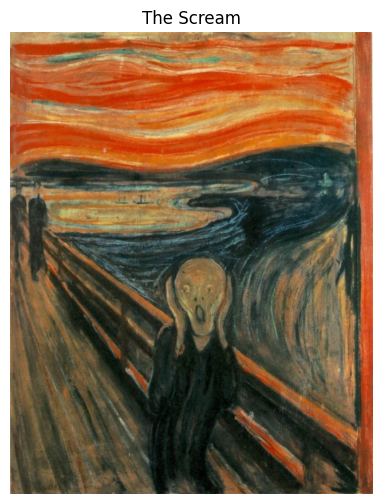

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

# 圖片網址
url = "https://upload.wikimedia.org/wikipedia/commons/f/f4/The_Scream.jpg"
filename = "scream.jpg"

# 🔧 加上 header 避免被 Wikimedia 拒絕
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
    out_file.write(response.read())

# 讀取影像
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 顯示原圖
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("The Scream")
plt.axis('off')
plt.show()


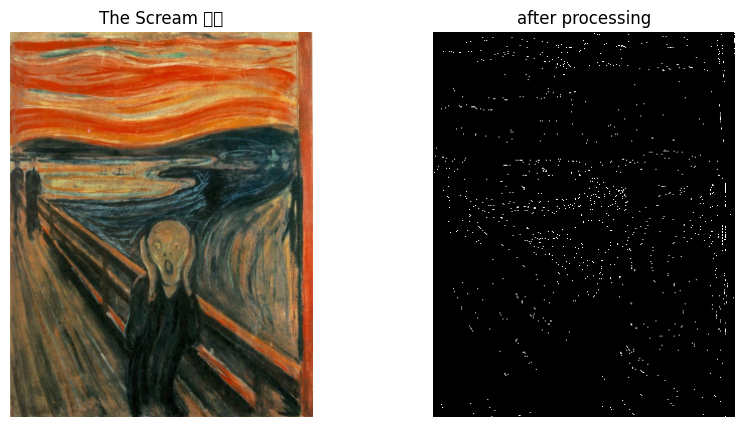

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import argparse

In [ ]:
def process_image(image_path, blur_kernel=(5, 5), canny_low=5, canny_high=20, subsample_factor=10):
    """
    Process an image with edge detection and subsampling
    
    Args:
        image_path: Path to the input image
        blur_kernel: Kernel size for Gaussian blur
        canny_low: Lower threshold for Canny edge detection
        canny_high: Higher threshold for Canny edge detection
        subsample_factor: Factor by which to subsample the image
        
    Returns:
        tuple: (original image, processed image)
    """
    # Read and check if image is loaded successfully
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, blur_kernel, 0)
    
    # Canny edge detection
    edges = cv2.Canny(blur, canny_low, canny_high)
    
    # Otsu's thresholding for binarization
    _, binary = cv2.threshold(edges, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Subsampling for pixelated effect
    subsampled = binary[::subsample_factor, ::subsample_factor]
    
    return img, subsampled


In [ ]:
def display_results(original, processed, title1="Original Image", title2="Processed Image"):
    """Display the original and processed images side by side"""
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(title1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title(title2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [ ]:
def save_result(image, output_path):
    """Save the processed image to disk"""
    try:
        cv2.imwrite(output_path, image)
        print(f"Image saved to {output_path}")
        return True
    except Exception as e:
        print(f"Error saving image: {e}")
        return False


In [ ]:
# Parse command line arguments
parser = argparse.ArgumentParser(description='Process images with edge detection and subsampling')
parser.add_argument('image_path', help='Path to the input image')
parser.add_argument('--blur', type=int, default=5, help='Blur kernel size (odd integer)')
parser.add_argument('--canny_low', type=int, default=5, help='Lower threshold for Canny edge detection')
parser.add_argument('--canny_high', type=int, default=20, help='Higher threshold for Canny edge detection')
parser.add_argument('--subsample', type=int, default=10, help='Subsampling factor')
parser.add_argument('--save', help='Path to save the processed image')

args = parser.parse_args()

# Ensure blur kernel size is odd
blur_kernel = (args.blur if args.blur % 2 == 1 else args.blur + 1, 
              args.blur if args.blur % 2 == 1 else args.blur + 1)

try:
    # Process the image
    original, processed = process_image(
        args.image_path, 
        blur_kernel=blur_kernel,
        canny_low=args.canny_low,
        canny_high=args.canny_high,
        subsample_factor=args.subsample
    )
    
    # Display results
    display_results(original, processed, "Original Image", "Edge Detection + Subsampling")
    
    # Save if requested
    if args.save:
        # Convert binary image to proper format for saving
        output_image = np.zeros((processed.shape[0], processed.shape[1]), dtype=np.uint8)
        output_image[:] = processed * 255
        save_result(output_image, args.save)
        
except Exception as e:
    print(f"Error processing image: {e}")